In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import koreanize_matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# CSV 파일 불러오기
daily = pd.read_csv("서울교통공사_일별통행통계_20251231.csv", encoding="cp949")
monthly = pd.read_csv("서울교통공사_월별 승하차인원_20251231.csv", encoding="cp949")

# 데이터 기본 정보 확인
print("===== 일별통행통계 =====")
print(daily.shape)
print(daily.columns.tolist())
display(daily.head())

print("\n===== 월별 승하차인원 =====")
print(monthly.shape)
print(monthly.columns.tolist())
display(monthly.head())

===== 일별통행통계 =====
(2604620, 31)
['연번', '수송일자', '호선', '역명', '승하차구분', '권종', '승객유형', '04시', '05시', '06시', '07시', '08시', '09시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시', '19시', '20시', '21시', '22시', '23시', '00시', '01시', '02시', '03시']


,연번,수송일자,호선,역명,승하차구분,권종,승객유형,04시,05시,06시,...,18시,19시,20시,21시,22시,23시,00시,01시,02시,03시
0,1,2025-01-01,1,서울역,승차,선불카드,일반,5,94,95,...,1136,1013,832,897,571,342,16,0,0,0
1,2,2025-01-01,1,서울역,하차,선불카드,일반,1,73,194,...,734,663,600,477,318,134,48,0,0,0
2,3,2025-01-01,1,서울역,승차,선불카드,우대권,4,34,52,...,249,209,151,132,75,25,0,0,0,0
3,4,2025-01-01,1,서울역,하차,선불카드,우대권,1,47,133,...,188,130,103,57,34,13,2,0,0,0
4,5,2025-01-01,1,서울역,승차,선불카드,어린이,0,1,0,...,40,24,15,7,3,4,1,0,0,0



===== 월별 승하차인원 =====
(3432, 6)
['연번', '호선', '고유역번호(외부역코드)', '역명', '수송연월', '승하차인원수']


,연번,호선,고유역번호(외부역코드),역명,수송연월,승하차인원수
0,1,1,150,서울역(1),2025-01,3651931
1,2,1,151,시청(1),2025-01,1406021
2,3,1,152,종각,2025-01,2017031
3,4,1,153,종로3가(1),2025-01,1338823
4,5,1,154,종로5가,2025-01,1230222


In [2]:
print(daily.columns.tolist())
print(monthly.columns.tolist())

['연번', '수송일자', '호선', '역명', '승하차구분', '권종', '승객유형', '04시', '05시', '06시', '07시', '08시', '09시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시', '19시', '20시', '21시', '22시', '23시', '00시', '01시', '02시', '03시']
['연번', '호선', '고유역번호(외부역코드)', '역명', '수송연월', '승하차인원수']


In [3]:

# ==========================================
# daily 시간대 컬럼
# ==========================================

hour_cols = [
    "04시", "05시", "06시", "07시",
    "08시", "09시", "10시", "11시",
    "12시", "13시", "14시", "15시",
    "16시", "17시", "18시", "19시",
    "20시", "21시", "22시", "23시",
    "00시", "01시", "02시", "03시"
]


# ==========================================
# daily 시간대 데이터 숫자형 변환
# ==========================================

for col in hour_cols:
    daily[col] = pd.to_numeric(
        daily[col],
        errors="coerce"
    ).fillna(0)


# ==========================================
# monthly 이용객 수 숫자형 변환
# ==========================================

monthly["승하차인원수"] = pd.to_numeric(
    monthly["승하차인원수"],
    errors="coerce"
).fillna(0)


# 날짜 형식 변환
daily["수송일자"] = pd.to_datetime(
    daily["수송일자"],
    errors="coerce"
)

monthly["수송연월"] = pd.to_datetime(
    monthly["수송연월"],
    errors="coerce"
)


# 데이터프레임의 행(row)과 열(column) 개수 확인
print("daily 행/열:", daily.shape)
print("monthly 행/열:", monthly.shape)


# daily 데이터의 결측치 개수 확인
print("\n[ daily 결측치 ]")
print(daily.isnull().sum())


# monthly 데이터의 결측치 개수 확인
print("\n[ monthly 결측치 ]")
print(monthly.isnull().sum())


# daily 데이터의 주요 컬럼을 확인하기 위해 앞부분 5개 행 출력
print("\n[ daily ]")
print(daily[["수송일자", "호선", "역명", "승하차구분"]].head())


# monthly 데이터의 주요 컬럼을 확인하기 위해 앞부분 5개 행 출력
print("\n[ monthly ]")
print(monthly[["수송연월", "호선", "역명", "승하차인원수"]].head())


display("전처리 완료")
display(daily.head())
display(monthly.head())

daily 행/열: (2604620, 31)
monthly 행/열: (3432, 6)

[ daily 결측치 ]
연번       0
수송일자     0
호선       0
역명       0
승하차구분    0
권종       0
승객유형     0
04시      0
05시      0
06시      0
07시      0
08시      0
09시      0
10시      0
11시      0
12시      0
13시      0
14시      0
15시      0
16시      0
17시      0
18시      0
19시      0
20시      0
21시      0
22시      0
23시      0
00시      0
01시      0
02시      0
03시      0
dtype: int64

[ monthly 결측치 ]
연번              0
호선              0
고유역번호(외부역코드)    0
역명              0
수송연월            0
승하차인원수          0
dtype: int64

[ daily ]
        수송일자  호선   역명 승하차구분
0 2025-01-01   1  서울역    승차
1 2025-01-01   1  서울역    하차
2 2025-01-01   1  서울역    승차
3 2025-01-01   1  서울역    하차
4 2025-01-01   1  서울역    승차

[ monthly ]
        수송연월  호선       역명   승하차인원수
0 2025-01-01   1   서울역(1)  3651931
1 2025-01-01   1    시청(1)  1406021
2 2025-01-01   1       종각  2017031
3 2025-01-01   1  종로3가(1)  1338823
4 2025-01-01   1     종로5가  1230222


'전처리 완료'

,연번,수송일자,호선,역명,승하차구분,권종,승객유형,04시,05시,06시,...,18시,19시,20시,21시,22시,23시,00시,01시,02시,03시
0,1,2025-01-01,1,서울역,승차,선불카드,일반,5,94,95,...,1136,1013,832,897,571,342,16,0,0,0
1,2,2025-01-01,1,서울역,하차,선불카드,일반,1,73,194,...,734,663,600,477,318,134,48,0,0,0
2,3,2025-01-01,1,서울역,승차,선불카드,우대권,4,34,52,...,249,209,151,132,75,25,0,0,0,0
3,4,2025-01-01,1,서울역,하차,선불카드,우대권,1,47,133,...,188,130,103,57,34,13,2,0,0,0
4,5,2025-01-01,1,서울역,승차,선불카드,어린이,0,1,0,...,40,24,15,7,3,4,1,0,0,0


,연번,호선,고유역번호(외부역코드),역명,수송연월,승하차인원수
0,1,1,150,서울역(1),2025-01-01,3651931
1,2,1,151,시청(1),2025-01-01,1406021
2,3,1,152,종각,2025-01-01,2017031
3,4,1,153,종로3가(1),2025-01-01,1338823
4,5,1,154,종로5가,2025-01-01,1230222


In [ ]:
# =========================
# 시간대별 이용량 분석
# =========================

# 분석할 시간대 컬럼 지정
hour_cols = [
    "04시", "05시", "06시", "07시",
    "08시", "09시", "10시", "11시",
    "12시", "13시", "14시", "15시",
    "16시", "17시", "18시", "19시",
    "20시", "21시", "22시", "23시",
    "00시", "01시", "02시", "03시"
]

hourly_usage = daily[hour_cols].sum()

print(hourly_usage)



04시       412969
05시     25901995
06시     75846927
07시    185052705
08시    310761233
09시    208773310
10시    148588950
11시    144821728
12시    154507688
13시    163720109
14시    163231903
15시    179578131
16시    206470142
17시    261960335
18시    325378692
19시    204329357
20시    147030571
21시    133902367
22시    110817424
23시     57572922
00시     14690975
01시       492400
02시         3119
03시            1
dtype: int64


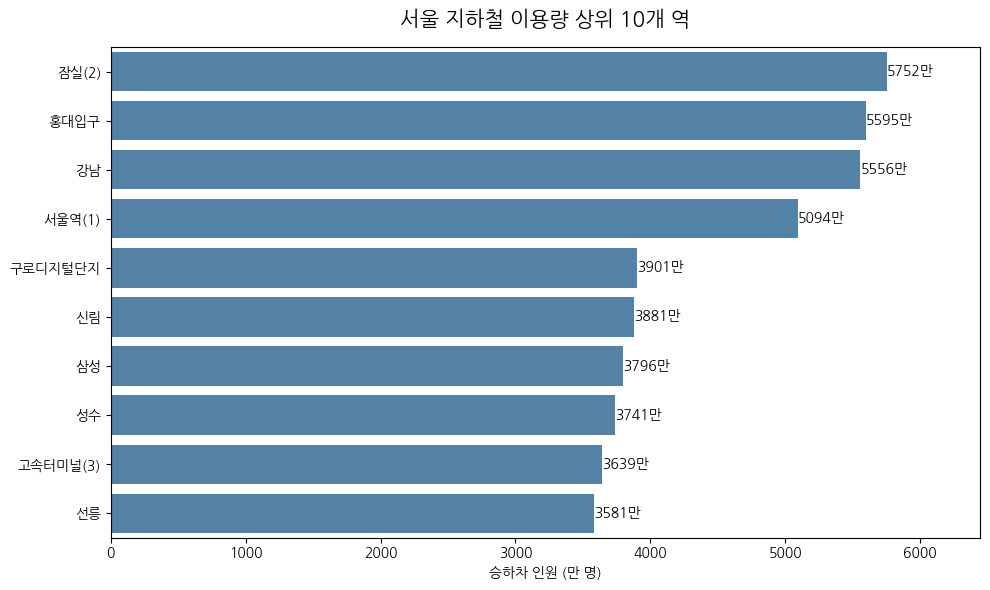

In [ ]:
#1. 이용량이 많은 역은 어디인가?
# ==========================================
# 서울 자하철 이용량 상위 10개역
# ==========================================
station_total = (
    monthly
    .groupby("역명")["승하차인원수"]
    .sum()
    .sort_values(ascending=False)
)
# 상위 10개 역
top10 = station_total.head(10) / 10000

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top10.values,
    y=top10.index,
    color="steelblue"
)

plt.title("서울 지하철 이용량 상위 10개 역", fontsize=15, pad=15)
plt.xlabel("승하차 인원 (만 명)")
plt.ylabel("")

# 막대 끝에 수치 표시
for i, value in enumerate(top10.values):
    ax.text(
        value + 0.3,
        i,
        f"{value:.0f}만",
        va="center",
        fontsize=10
    )

# X축 범위에 여유 공간 추가
plt.xlim(0, top10.max() * 1.12)

plt.tight_layout()
plt.show()

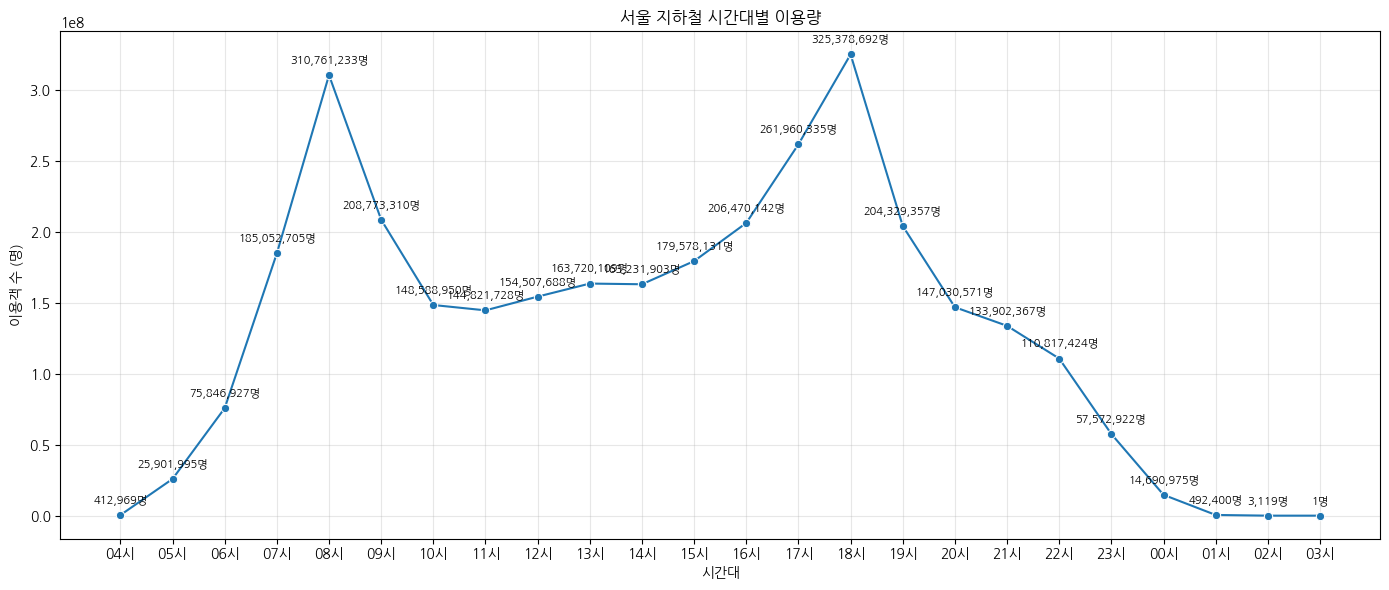

가장 이용객이 많은 시간대: 18시
이용객 수: 325,378,692명


In [ ]:

#2. 이용객이 집중되는 시간대
# ==========================================
# 서울 지하철 시간대별 이용량
# ==========================================

plt.figure(figsize=(14, 6))

# 실제 이용객 수 그대로 사용
ax = sns.lineplot(
    x=hourly_usage.index,
    y=hourly_usage.values,
    marker="o"
)

plt.title("서울 지하철 시간대별 이용량")
plt.xlabel("시간대")
plt.ylabel("이용객 수 (명)")
plt.grid(alpha=0.3)

# 각 점에 실제 이용객 수 표시
for i, value in enumerate(hourly_usage.values):
    ax.annotate(
        f"{value:,}명",
        (i, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# 가장 이용객이 많은 시간대와 실제 이용객 수 출력
print(f"가장 이용객이 많은 시간대: {hourly_usage.idxmax()}")
print(f"이용객 수: {hourly_usage.max():,}명")

In [ ]:
line_total = (
    monthly
    .groupby("호선")["승하차인원수"]
    .sum()
    .sort_values(ascending=False)
)

display(line_total)

,승하차인원수
호선,
2,1013142995
5,471573581
7,414152559
3,382714832
4,381047550
6,244968081
1,186648895
8,147474186
9,50238581


호선별 총 이용량


,0
호선,
2,1009002315
5,467970352
7,411695572
3,380817362
4,378894783
6,243104286
1,185914419
8,146446864


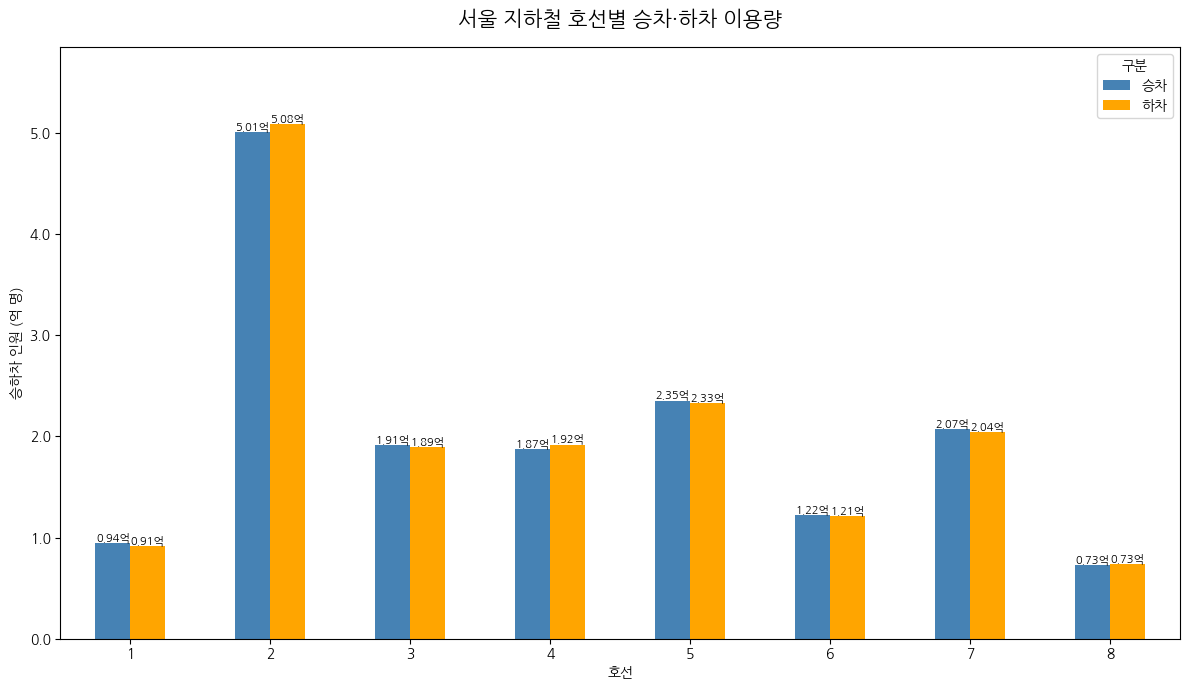

이용량이 가장 많은 호선: 2
이용량이 가장 적은 호선: 8
호선별 총 이용량 (억 명)


,0
호선,
2,10.09
5,4.68
7,4.12
3,3.81
4,3.79
6,2.43
1,1.86
8,1.46


In [ ]:
# ==========================================
# 하루 단위 승하차 인원 계산
# ==========================================

daily["일일이용량"] = (
    daily[hour_cols]
    .sum(axis=1)
)


# ==========================================
# 호선별 승차 / 하차 이용량 계산
# ==========================================

line_usage = (
    daily
    .groupby(
        ["호선", "승하차구분"]
    )["일일이용량"]
    .sum()
    .unstack(
        fill_value=0
    )
)


# ==========================================
# 호선별 총 이용량 계산
# 승차 + 하차
# ==========================================

line_total = (
    line_usage
    .sum(axis=1)
    .sort_values(
        ascending=False
    )
)


# ==========================================
# 호선별 총 이용량 확인
# 실제 계산값은 원래 인원수 그대로 유지
# ==========================================

print("호선별 총 이용량")
display(line_total)


# ==========================================
# 그래프용 데이터
# 억 명 단위로 변환
# ==========================================

line_usage_display = (
    line_usage / 100_000_000
)


# ==========================================
# 그래프
# ==========================================

ax = line_usage_display.plot(
    kind="bar",
    figsize=(12, 7),
    color=[
        "steelblue",
        "orange"
    ]
)


# ==========================================
# 그래프 제목
# ==========================================

plt.title(
    "서울 지하철 호선별 승차·하차 이용량",
    fontsize=15,
    pad=15
)

plt.xlabel(
    "호선"
)

plt.ylabel(
    "승하차 인원 (억 명)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="구분"
)


# ==========================================
# 막대 위에 이용량 표시
# ==========================================

for container in ax.containers:

    for bar in container:

        height = bar.get_height()

        if height > 0:

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,

                height,

                f"{height:.2f}억",

                ha="center",
                va="bottom",

                fontsize=8
            )


# ==========================================
# Y축 과학적 표기 제거
# ==========================================

from matplotlib.ticker import FuncFormatter

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:.1f}"
    )
)


# ==========================================
# Y축 범위
# ==========================================

ax.set_ylim(
    0,
    line_usage_display.max().max() * 1.15
)


plt.tight_layout()

plt.show()


# ==========================================
# 가장 많은 / 적은 호선
# ==========================================

print(
    f"이용량이 가장 많은 호선: "
    f"{line_total.idxmax()}"
)

print(
    f"이용량이 가장 적은 호선: "
    f"{line_total.idxmin()}"
)


# ==========================================
# 호선별 총 이용량
# 억 명 단위로 보기 좋게 변환
# ==========================================

line_total_display = (
    line_total
    / 100_000_000
)


# 소수점 둘째 자리까지 표시
line_total_display = (
    line_total_display
    .round(2)
)


print(
    "호선별 총 이용량 (억 명)"
)

display(
    line_total_display
)


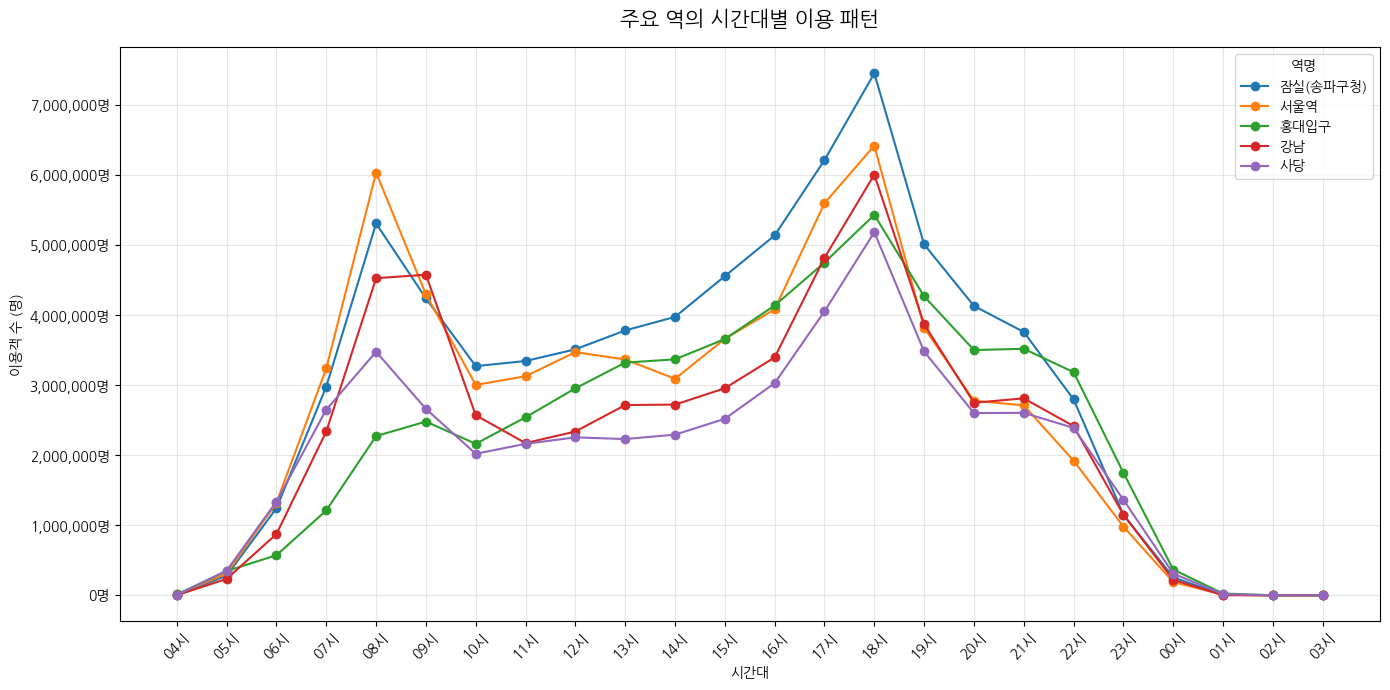

In [ ]:
#역별·시간대별 이용 패턴은 어떻게 다른가?


# 역별·시간대별 이용량
station_hourly = (
    daily
    .groupby("역명")[hour_cols]
    .sum()
)

# 이용량 상위 5개 역
station_total = station_hourly.sum(axis=1).sort_values(ascending=False)
top5_stations = station_total.head(5).index

# 그래프
plt.figure(figsize=(14, 7))

for station in top5_stations:
    plt.plot(
        hour_cols,
        station_hourly.loc[station],
        marker="o",
        label=station
    )

plt.title("주요 역의 시간대별 이용 패턴", fontsize=15, pad=15)
plt.xlabel("시간대")
plt.ylabel("이용객 수 (명)")  # Y축 단위
plt.xticks(rotation=45)
plt.legend(title="역명")
plt.grid(alpha=0.3)

# Y축 숫자에 천 단위 콤마 표시
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:,.0f}명")
)

plt.tight_layout()
plt.show()

역명
잠실(송파구청)    31190958
서울역         29395489
강남          26126124
사당          21498216
구로디지털단지     20421057
홍대입구        20406895
역삼          20089399
시청          19599031
삼성(무역센터)    19298528
선릉          18280399
dtype: int64


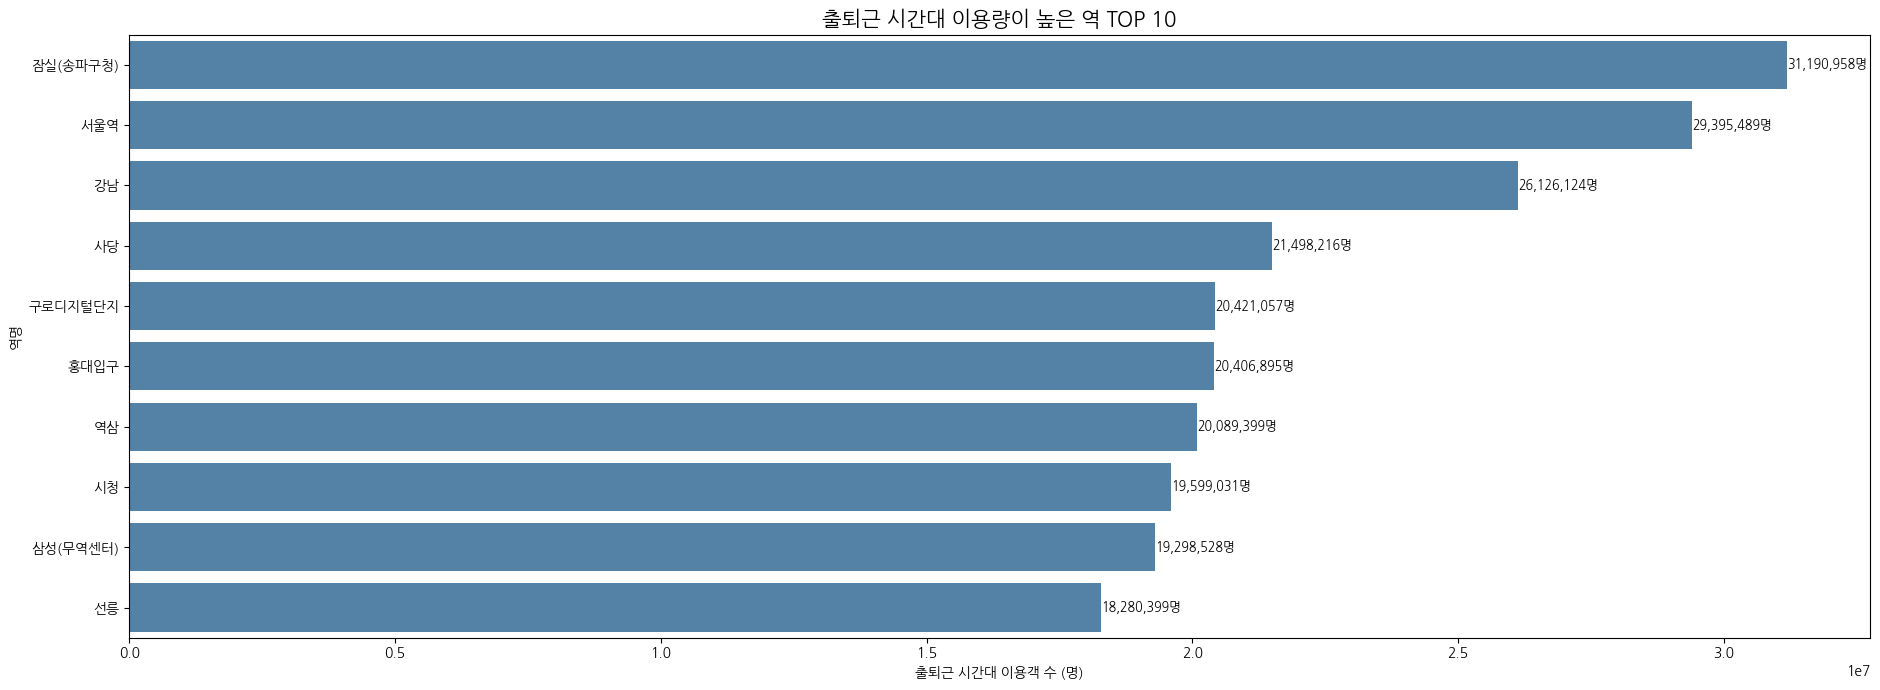

In [ ]:
# 출퇴근 기준
commute_cols = [
    "07시", "08시", "09시",
    "17시", "18시", "19시"
]

# 역별 출퇴근 시간대 이용량
commute_usage = (
    daily
    .groupby("역명")[commute_cols]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

# 출퇴근 시간대 이용량 상위 10개 역
top10_commute = commute_usage.head(10)

print(top10_commute)

plt.figure(figsize=(19, 7))

ax = sns.barplot(
    x=top10_commute.values,
    y=top10_commute.index,
    color="steelblue"
)

plt.title("출퇴근 시간대 이용량이 높은 역 TOP 10", fontsize=15)
plt.xlabel("출퇴근 시간대 이용객 수 (명)")
plt.ylabel("역명")

for i, value in enumerate(top10_commute.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}명",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

,승하차인원수
수송연월,
2025-01,242611320
2025-02,250156962
2025-03,285352815
2025-04,288162061
2025-05,284179960
2025-06,267151551
2025-07,280014012
2025-08,263591190
2025-09,285025149


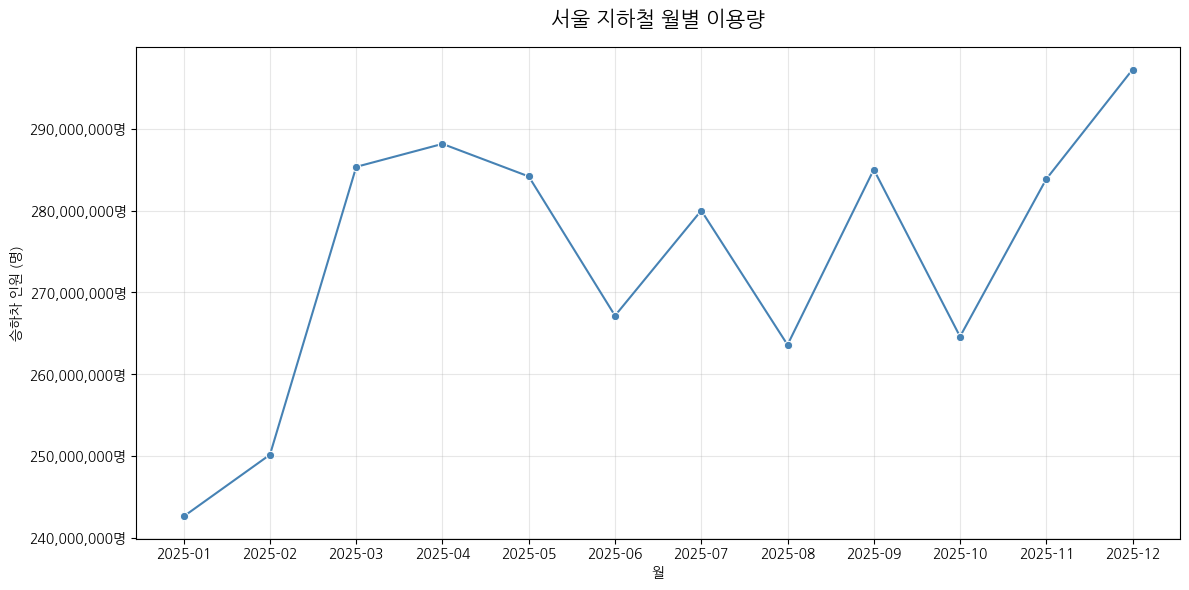

이용량이 가장 많은 달: 2025-12
이용량: 297,253,375명
이용량이 가장 적은 달: 2025-01
이용량: 242,611,320명


In [ ]:
# 월별 이용량은 어떻게 변화하는가?

# 월별 전체 이용량
monthly_usage = (
    monthly
    .groupby("수송연월")["승하차인원수"]
    .sum()
    .sort_index()
)

display(monthly_usage)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    x=monthly_usage.index,
    y=monthly_usage.values,
    marker="o",
    color="steelblue"
)

plt.title("서울 지하철 월별 이용량", fontsize=15, pad=15)
plt.xlabel("월")
plt.ylabel("승하차 인원 (명)")
plt.grid(alpha=0.3)

# Y축에 명 단위 표시
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:,.0f}명")
)

plt.tight_layout()
plt.show()

print(f"이용량이 가장 많은 달: {monthly_usage.idxmax()}")
print(f"이용량: {monthly_usage.max():,}명")

print(f"이용량이 가장 적은 달: {monthly_usage.idxmin()}")
print(f"이용량: {monthly_usage.min():,}명")

In [ ]:

# ==========================================
# 서울 지하철 이용 패턴 분석 결과
# ==========================================

max_month = str(monthly_usage.idxmax())
min_month = str(monthly_usage.idxmin())

result = pd.DataFrame({
    "분석 항목": [
        "가장 이용객이 많은 시간대",
        "시간대 이용객 수",
        "이용량이 가장 많은 역",
        "역 이용량",
        "이용량이 가장 많은 월",
        "월 이용량",
        "이용량이 가장 적은 월",
        "월 이용량"
    ],
    "분석 결과": [
        hourly_usage.idxmax(),
        f"{hourly_usage.max():,}명",
        station_total.idxmax(),
        f"{station_total.max():,}명",
        max_month,
        f"{monthly_usage.max():,}명",
        min_month,
        f"{monthly_usage.min():,}명"
    ]
})
# 인덱스를 1부터 시작
result.index = range(1, len(result) + 1)

display(result)


,분석 항목,분석 결과
1,가장 이용객이 많은 시간대,18시
2,시간대 이용객 수,"325,378,692명"
3,이용량이 가장 많은 역,잠실(송파구청)
4,역 이용량,"72,381,262명"
5,이용량이 가장 많은 월,2025-12
6,월 이용량,"297,253,375명"
7,이용량이 가장 적은 월,2025-01
8,월 이용량,"242,611,320명"


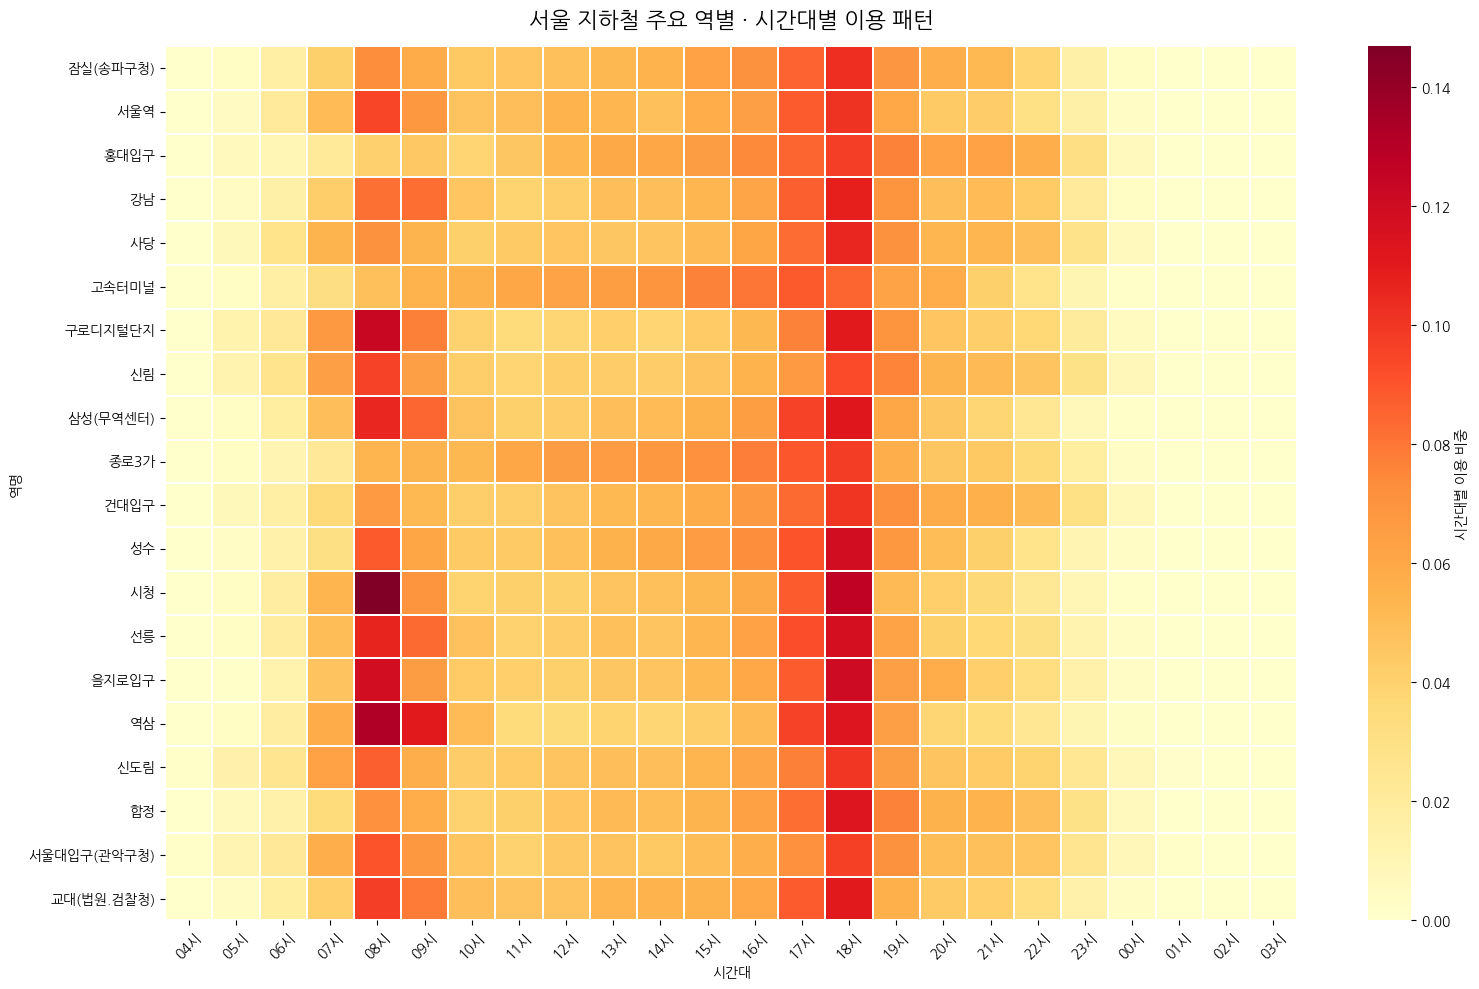

In [ ]:
# ==========================================
# 역별 · 시간대별 이용 패턴 히트맵
# ==========================================

# 1. 역별 시간대 이용량 합계
station_hourly = (
    daily
    .groupby("역명")[hour_cols]
    .sum()
)

# 2. 역별 총 이용량 계산
station_hourly["총이용량"] = station_hourly[hour_cols].sum(axis=1)

# 3. 이용량 상위 20개 역
top20_stations = (
    station_hourly["총이용량"]
    .sort_values(ascending=False)
    .head(20)
    .index
)

# 4. 상위 20개 역의 시간대별 데이터
heatmap_data = station_hourly.loc[
    top20_stations,
    hour_cols
]

# 5. 역별 시간대 이용 비중 계산
heatmap_ratio = heatmap_data.div(
    heatmap_data.sum(axis=1),
    axis=0
)

# ==========================================
# 6. 히트맵 출력
# ==========================================

plt.figure(figsize=(16, 10))

sns.heatmap(
    heatmap_ratio,
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "시간대별 이용 비중"},
    fmt=".2%"
)

plt.title(
    "서울 지하철 주요 역별 · 시간대별 이용 패턴",
    fontsize=16,
    pad=15
)

plt.xlabel("시간대")
plt.ylabel("역명")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()
